In [15]:
import math
import scipy.stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Luke Lawrence ML HW 1 Dr. Milani

## Understanding the data

### 1. First inspection

a) We load the dataset from the CSV file, and display it here. As we can see printed here, there are 8 columns and 40 rows. 

b) The names are printed below.

c) All of the variables are numeric.

d) I would choose final_score as the prediction target because each variable is independent, but the final score is the only variable we can infer given the independent ones - it is dependent. (Note that student_id is more of a categorical variable not an indepdendent or dependent variable.)

In [3]:
df = pd.read_csv('week2_student_learning_data.csv')
print(df.head())
print(f"Columns: {len(df.columns)}\n Rows: {len(df)}")
print(f"Column names: {df.columns}")

   student_id  study_hours_per_week  attendance_rate  \
0           1                   2.0               58   
1           2                   3.5               62   
2           3                   4.0               67   
3           4                   5.0               70   
4           5                   5.5               72   

   practice_quizzes_completed  office_hours_visits  homework_average  \
0                           0                  4.5                35   
1                           1                  5.0                42   
2                           1                  5.5                47   
3                           2                  6.0                49   
4                           2                  6.0                52   

   sleep_hours_per_night  final_score  
0                    7.0           74  
1                    6.5           78  
2                    7.5           82  
3                    7.0           85  
4                    6.0      

### 2. Summary statistics

Let's compute the mean, median, standard deviation, and min and max of 3 variables. 
We'll choose:
* study_hours_per_week
* office_hours_visits
* sleep_hours_per_night
  

In [4]:
data1 = np.array(df["study_hours_per_week"])
data2 = np.array(df["office_hours_visits"])
data3 = np.array(df["sleep_hours_per_night"])

data1_mean = np.mean(data1)
data2_mean = np.mean(data2)
data3_mean = np.mean(data3)

data1_median = np.median(data1)
data2_median = np.median(data2)
data3_median = np.median(data3)

data1_std = np.std(data1)
data2_std = np.std(data2)
data3_std = np.std(data3)

data1_min = np.min(data1)
data2_min = np.min(data2)
data3_min = np.min(data3)

data1_max = np.max(data1)
data2_max = np.max(data2)
data3_max = np.max(data3)

In [5]:
spreads = np.array([data1_std, data2_std, data3_std])
means = np.array([data1_mean, data2_mean, data3_mean])
medians = np.array([data1_median, data2_median, data3_median])
print(spreads)
print(means)
print(medians)
highest_spread = np.max(spreads)
print(highest_spread)
print("'study_hours_per_week' has the highest spread!")
print("The mean and median are pretty similar, but they are most different in the 'study_hours_per_week' column.")

[2.27894575 1.6345871  0.87891979]
[5.4875 6.125  6.7   ]
[5.75 6.   6.75]
2.2789457540713864
'study_hours_per_week' has the highest spread!
The mean and median are pretty similar, but they are most different in the 'study_hours_per_week' column.


### Findings

a) 'study_hours_per_week' has the highest spread!

b) The mean and median are pretty similar, but they are most different in the 'study_hours_per_week' column. 

c) These findings suggest that the amount of hours per week that students actually study varies a lot.

d) This could mean that there are outlier data points, and we need more investigation of the data, or it could simply mean that the amount of hours studied is a parameter that has high variability and potentially a big impact on the target prediction.

## Distribution and structure

### 3. Histograms - NEED TO LABEL!

We'll use the same variables as before.

a) The shape looks relatively like a normal distribution for all the data.

b) There is some slight skewing in the third dataset, 'sleep_hours_per_night,' otherwise there is none.

c) There are gaps but it seems to be from lack of large sample size.

d) I would trust the mean in this case, because even with varied bin sizes I'm still seeing a shape of a normal distribution.

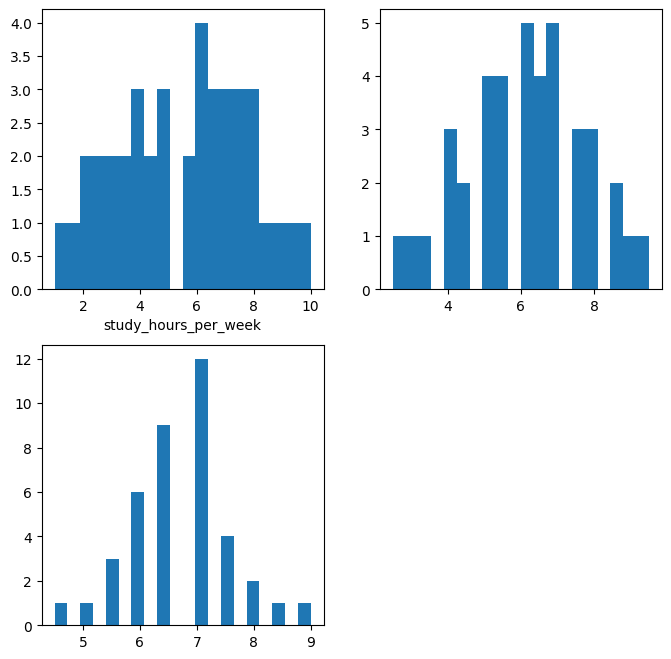

In [6]:
plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.hist(data1, 20)
plt.xlabel("study_hours_per_week")

plt.subplot(2,2,2)
plt.hist(data2, 20)

plt.subplot(2,2,3)
plt.hist(data3, 20)

plt.show()
plt.close()

### 4. Boxplots and outliers

a) sleep_hours_per_night has some outlier data.

b) This does match the data that I have in the histograms, because it shows the slight skewing in the histogram for sleep_hours_per_night, and more accurately shows the outlier behavior.

c) Outliers matter because they can skew the weights and biases used in models. For example, in linear regression the line can skew greatly one way towards an outlier.

d) Outliers should always be investigated, but not necessarily removed, because they may be representative of bad data capturing, bad hypothesis, or other pre-training cases that are important to handle.

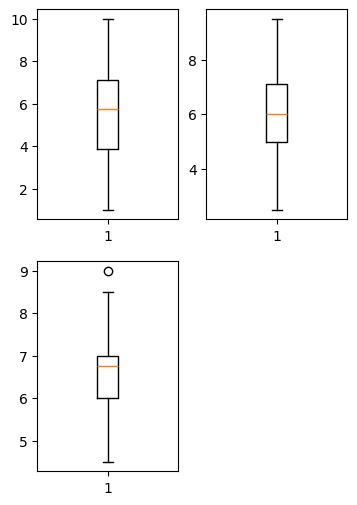

In [7]:
plt.figure(figsize=(4,6))
plt.subplot(2,2,1)
plt.boxplot(data1)
plt.subplot(2,2,2)
plt.boxplot(data2)
plt.subplot(2,2,3)
plt.boxplot(data3)
plt.show()
plt.close()

## Relationships between variables

### 5. Scatterplots 

a) There is a linear relationship. Note that these variables are both measured in time, so I couldn't plot homework_average along with these. 

b) Positive direction. The homework_average has a seemingly more correlated relationship. This is explored in the next section. The amount of hours slept per night has a negative correlation, and it is more loose.

c) The office hours visit metric has points that are more clustered toward a linear line.

d) It looks linear, and if you combined the two, you could probably come up with some line of best fit!

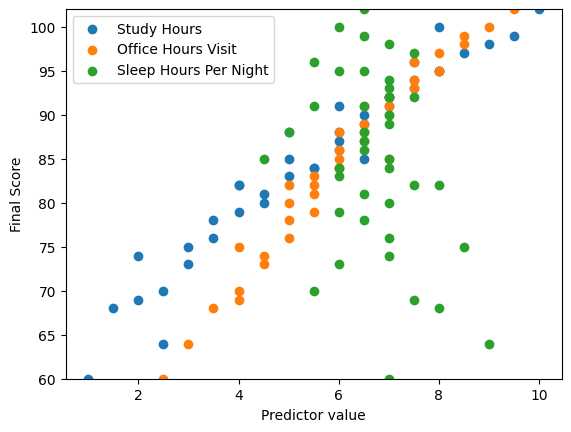

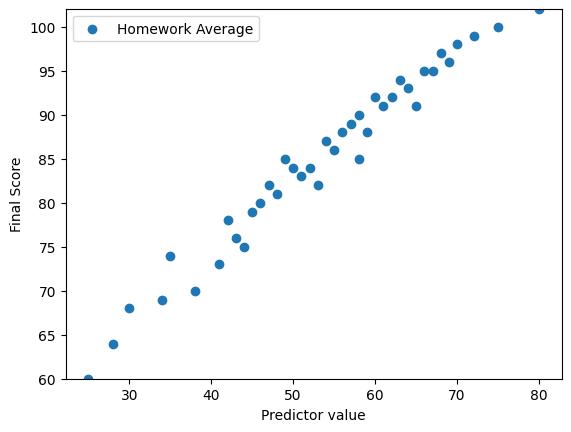

In [8]:
y = df["final_score"]
data4 = df["homework_average"]

plt.scatter(data1, y, label="Study Hours")
plt.scatter(data2, y, label="Office Hours Visit")
plt.scatter(data3, y, label="Sleep Hours Per Night")

plt.xlabel("Predictor value")
plt.ylabel("Final Score")
plt.ylim(np.min(y), np.max(y))
plt.legend()
plt.show()

plt.scatter(data4, y, label="Homework Average")

plt.xlabel("Predictor value")
plt.ylabel("Final Score")
plt.ylim(np.min(y), np.max(y))
plt.legend()
plt.show()

### 6. Correlation

a) The variable that correlates the most with final_score is homework_average, given by this table below. 

b) My other plots match in their relative level of correlation and the plots I've shown.

c) Yes, low correlation can be good because it can signify nonlinear relationships or hidden interactions. But for linear regression, it might make things fuzzier.

d) Correlation alone is not enough because it is simply a numeric value that represents a relationship, but does not explain the underlying cause, or take it into account. As data changes, a model based solely on correlation would often fail, especially as things got more complex and more factors got introduced.

In [9]:
df.corr()

,student_id,study_hours_per_week,attendance_rate,practice_quizzes_completed,office_hours_visits,homework_average,sleep_hours_per_night,final_score
student_id,1.000000,0.131858,0.263964,0.176166,0.093409,0.189191,-0.089939,0.067473
study_hours_per_week,0.131858,1.000000,0.881132,0.959719,0.975216,0.964783,-0.279579,0.967637
attendance_rate,0.263964,0.881132,1.000000,0.790970,0.886326,0.964293,-0.314086,0.934916
practice_quizzes_completed,0.176166,0.959719,0.790970,1.000000,0.944012,0.909034,-0.311209,0.903910
office_hours_visits,0.093409,0.975216,0.886326,0.944012,1.000000,0.970248,-0.348027,0.978678
homework_average,0.189191,0.964783,0.964293,0.909034,0.970248,1.000000,-0.363491,0.984351
sleep_hours_per_night,-0.089939,-0.279579,-0.314086,-0.311209,-0.348027,-0.363491,1.000000,-0.313993
final_score,0.067473,0.967637,0.934916,0.903910,0.978678,0.984351,-0.313993,1.000000


## Thinking like an ML Practitioner

### 7. Before building a model

a) The variables that seem most useful for prediction to me are homework_average because of the strong correlation, and office_hours_visits because of its correlation and normal looking distribution, and also because I personally think that this is a big reflector of high performance in a class, because it shows a student wants to learn and is engaged.

b) The hardest to interpret variable would probably be sleep_hours_per_night because it has such a loose correlation, and also because the method of survey is weak, because people aren't sure about how much they slept, the average can have extremes, like if a student pulls an all nighter, and other complex factors. The other data points give exact metrics that more closely reflect performance. Although hours slept is important, and it shouldn't be a discounted data point, it is just a  bit harder to work with.

c) Variables with outliers might need cleaning, and also it is important to note that different has different units, like, scores on tests, hours, or visits to office. Those things can get confusing if you don't understand the data before making a model.

d) Linear regression would work well here because most of these variables have a pretty strong correlation, and linear in form. If the factors were more complex, or if there were more factors, or potentially if the target values were more complex, nonlinear regression, or another model might need to be used.

## Probability and likelihood

### 8. Probability vs likelihood

a) Probability is the chance that an event will happen, given by the ratio of favorable outcomes and the number of total equally likely outcomes. Probability ranges from 0, being impossible, and 1, being totally certain. 

b) Likelihood measures how likely an outcome is, or the probability or chance.

c) An example might help. If we are given a fair coin, we can get asked what the chance of 5 heads is. This would be probability. If we were told that we got 5 heads in 5 flips, likelihood gives how likely the coin is to be fair. In probability, the parameters are non-changing but the data is variable. In likelihood, the parameters are changeable and the data is fixed.

d) This matters in ML because we often are given fixed data, and build models that constantly change the value weights of the parameters. Often, it is best to even disregard whole features, or change them drastically, normalize them, log-scale them, etc. Also, when we do this, we use the likelihood metric to assess the model performance, so it is important to understand the fundamentals of likelihood.

### 9. Likelihood intuition

a) We can reasonably assume the probability of heads is 0.70. 

b) The above value is the MLE or maximum likelihood estimate, which gives the specific probability that makes the observed data occur.

c) The intuitive estimate for pi is 0.7 as well, because we know there have been 10 coin flips, and the formula for experimental probability is the ratio of the number of times an event has occured over the total number of occurences - which gives 0.7 here. 

#### Some extra analysis:

Note that the theoretical probability is the ratio of the number of favorable outcomes over the total number of possible outcomes that are equally likely. We don't know that this is a fair coin - we don't know that the 10 outcomes we had are all equally likely, which is one reason we can't use theoretical probability here. Also, our sample size is too small. If it were a fair coin, the law of large numbers says that pi would probably tend towards 0.5 because the data would be an even split of heads and tails.

Here we show the binomial distribution, and see how probable it actually was to get 7 heads and 3 tails. The Binomial Distribution formula is: $P(X=k)=\binom{n}{k} \cdot p^k \cdot (1-p)^{n-k}$. Where n = 10 total flips, k = 7 heads observed, and p = 0.5, which is the probability for a fair coin. The $\binom{n}{k}$ term represents "n choose k" where n is the total number of items in the set and k is the number of items to be chosen. We use this in probability to determine the number of succesful outcomes in a sample space. The probability of one sequence is $(0.5)^10 = \frac{1}{1024}$. Multiply the number of ways we can get 7 heads by the probability of a sequence of 10 flips: $120 \times \frac{1}{1024} = 0.1172$, or $11.7\%$.

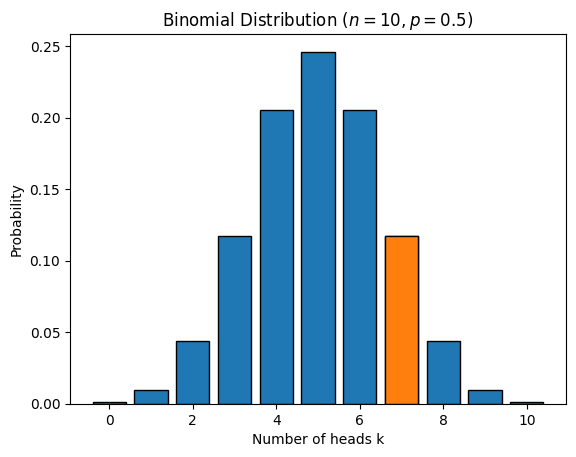

P(X = 7) = 0.1171875


In [47]:
n = 10
probability = 0.5
k = np.arange(0, 11)

binomial_distribution = lambda prob, n, k: math.comb(n, k) * prob**k * (1-prob)**(n-k)

freq_table = []

for i in k:
    freq_table.append(binomial_distribution(probability, n, k[i]))
    
plt.bar(k, freq_table, edgecolor='black')
plt.title(f"Binomial Distribution $(n = 10, p = 0.5)$")
plt.xlabel("Number of heads k")
plt.ylabel("Probability")
plt.bar(7, binomial_probability(n, p, 7), edgecolor='black')
plt.show()

print("P(X = 7) =", binomial_probability(n, p, 7))

## Simulation

### 10. Python simulation

Let's first compare the plot with theoretical probability of getting 3 heads. If we are trying to get the expected value of 1 head, we know we have a 1/2 chance of getting it on the first go, and if it takes longer, we've used up a toss, and are still waiting for one head. So if $X$ is one head,: $\mathbb{E}[X] = \frac{1}{2}(1) + \frac{1}{2}(1 + E)$. Solving for E, we get 2. From 1 head to two heads, the expected value is also 2. So we know then for 3 heads, the expected value is 6, because $2 + 2 + 2 = 6$. This aligns with our plot and experimental data, because the plot tends towards 6. This shows the law of large numbers in action. This tells us that we can be more certain about data as the sample size becomes large.

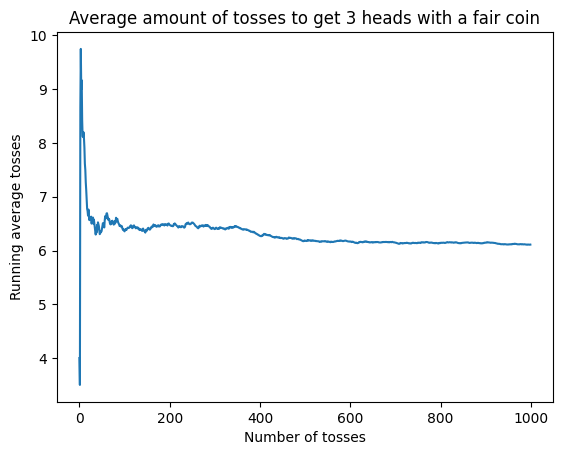

In [68]:
def coin_toss():
    if (np.random.rand() >= 0.5):
        return 1
    return 0
    
tosses_until_3 = []
avg_tosses_until_3 = []
tosses = 0
num_heads = 0

for i in range (1000):
    while(num_heads < 3):
        tosses += 1
        if (coin_toss() == 1):
            num_heads += 1
    tosses_until_3.append(tosses)
    avg_tosses_until_3.append(np.mean(tosses_until_3))
    tosses = 0
    num_heads = 0

x = np.arange(0, 1000)
plt.plot(x, avg_tosses_until_3)
plt.title("Average amount of tosses to get 3 heads with a fair coin")
plt.xlabel("Number of tosses")
plt.ylabel("Running average tosses")
plt.show()